# Modelo de Predicción Player + Team Attributes con Rachas Recientes

MODELO XGBOOST

TARGET: Home Win (H), Draw (D), Away Win (A)

FEATURES: Player Attributes + Team Attributes + Team Streaks (3, 5, 10 partidos)

Este notebook extiende la arquitectura base agregando variables macro de rendimiento dinámico. Se calculan las rachas de puntos obtenidos por los equipos local y visitante en sus últimos 3, 5 y 10 compromisos, mitigando el data leakage temporal mediante desplazamientos indexados.

In [1]:
# HELPERS
import sqlite3 as sql
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

**Cargamos los Dataframes Necesarios**

Match

In [2]:
conn = sql.connect('../../data/database.sqlite')
query = "SELECT * FROM Match ORDER BY date ASC"
df_match = pd.read_sql_query(query, conn)
df_match['date'] = pd.to_datetime(df_match['date'])

Se crea una columna Full Time Results (FTR) con las clases Home Win (H), Draw (D), Away Win (A) numerizadas (0, 1 y 2 respectivamente).

In [3]:
conditions = [
    df_match["home_team_goal"] > df_match["away_team_goal"],
    df_match["home_team_goal"] < df_match["away_team_goal"]
]

choices = [0, 2]

df_match["FTR"] = np.select(conditions, choices, default=1) # type: ignore

**Cálculo de Rachas de Equipos (Ingeniería de Features)**

Para calcular el rendimiento reciente sin introducir data leakage, se descompone el dataframe estructurado por partido en una serie cronológica por equipo. Se asignan 3 puntos por victoria, 1 por empate y 0 por derrota. Posteriormente, se calculan las medias móviles truncadas (`shift(1)`) para las ventanas temporales de interés.

In [4]:
home_stats = df_match[['match_api_id', 'date', 'home_team_api_id', 'FTR']].copy()
home_stats.columns = ['match_api_id', 'date', 'team_api_id', 'FTR']  # type: ignore
home_stats['points'] = np.select([home_stats['FTR'] == 0, home_stats['FTR'] == 1], [3, 1], default=0) # type: ignore

away_stats = df_match[['match_api_id', 'date', 'away_team_api_id', 'FTR']].copy()
away_stats.columns = ['match_api_id', 'date', 'team_api_id', 'FTR'] # type: ignore
away_stats['points'] = np.select([away_stats['FTR'] == 2, away_stats['FTR'] == 1], [3, 1], default=0) # type: ignore

team_history = pd.concat([home_stats, away_stats], axis=0).sort_values(by=['team_api_id', 'date']) # type: ignore

windows = [3, 5, 10, 15, 20]
for w in windows:
    team_history[f'streak_{w}'] = (
        team_history.groupby('team_api_id')['points']
        .transform(lambda x: x.rolling(window=w, min_periods=1).mean().shift(1))
    )

home_streaks = team_history.loc[team_history.index.isin(df_match.index) & (team_history.match_api_id.isin(df_match.match_api_id))]
# Re-extraemos mapeando por match_api_id para reincorporar al dataframe maestro
df_match = df_match.merge(
    team_history[['match_api_id', 'team_api_id', 'streak_3', 'streak_5', 'streak_10', 'streak_15', 'streak_20']],
    left_on=['match_api_id', 'home_team_api_id'],
    right_on=['match_api_id', 'team_api_id'],
    how='left'
).rename(columns={'streak_3': 'home_streak_3', 'streak_5': 'home_streak_5', 'streak_10': 'home_streak_10', 'streak_15': 'home_streak_15', 'streak_20': 'home_streak_20'}).drop(columns=['team_api_id'])

df_match = df_match.merge(
    team_history[['match_api_id', 'team_api_id', 'streak_3', 'streak_5', 'streak_10', 'streak_15', 'streak_20']],
    left_on=['match_api_id', 'away_team_api_id'],
    right_on=['match_api_id', 'team_api_id'],
    how='left'
).rename(columns={'streak_3': 'away_streak_3', 'streak_5': 'away_streak_5', 'streak_10': 'away_streak_10', 'streak_15': 'away_streak_15', 'streak_20': 'away_streak_20'}).drop(columns=['team_api_id'])

Se definen las columnas con proveedores de casas de apuestas para eliminarlas del dataframe de partidos

In [5]:
betting_columns = [
    'LBH', 'LBD', 'LBA', 
    'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 
    'SJH', 'SJD', 'SJA', 'VCH', 'VCD', 'VCA', 
    'GBH', 'GBD', 'GBA', 'BSH', 'BSD', 'BSA'
]
df_match = df_match.drop(columns=betting_columns)

Se eliminan el resto de columnas con datos nominales, reteniendo explícitamente las columnas de rachas recién calculadas.

In [6]:
streak_cols = ['home_streak_3', 'home_streak_5', 'home_streak_10', 'away_streak_3', 'away_streak_5', 'away_streak_10']
id_target_cols = ['match_api_id', 'FTR']
numeric_match = df_match.select_dtypes(include="number")

# Aseguramos la retención de las columnas base para el merge secuencial
df_match_filtered = df_match[list(set(numeric_match.columns.tolist() + streak_cols + id_target_cols))]

Player_Attributes

In [7]:
query = "SELECT * FROM Player_Attributes"
df_player_attributes = pd.read_sql_query(query, conn)

Se obtiene la última versión actualizada con los datos del jugador. Se eliminan los atributos nominales para quedarnos con los numéricos, es decir sus estadísticas como jugador.

In [8]:
player_attrs = (
    df_player_attributes
    .sort_values("date")
    .drop_duplicates("player_api_id", keep="last")
    .select_dtypes(include="number")
)

Team_Attributes

In [9]:
query = "SELECT * FROM Team_Attributes"
df_team_attributes = pd.read_sql_query(query, conn)

Se obtiene la última versión actualizada con los datos del equipo. Se eliminan los atributos nominales para quedarnos con los numéricos, es decir sus estadísticas tácticas como equipo.

In [10]:
team_attrs = (
    df_team_attributes
    .sort_values("date")
    .drop_duplicates("team_api_id", keep="last")
    .select_dtypes(include="number")
)

Se identifican las columnas del partido que contienen el ID de cada jugador titular (`home_player_1`...`home_player_11`, `away_player_1`...`away_player_11`, excluyendo las columnas `home_player_X*`/`home_player_Y*` de coordenadas de formación) y el ID de cada equipo (`home_team_api_id`, `away_team_api_id`, excluyendo `home_team_goal`/`away_team_goal` por ser la fuente del target).

In [11]:
player_cols = [c for c in df_match_filtered.columns if re.fullmatch(r"(home|away)_player_\d+", c)]
team_cols = [c for c in df_match_filtered.columns if re.match(r"(home|away)_team_api_id", c)]

print(f"Columnas de jugadores encontradas: {len(player_cols)}")
print(f"Columnas de equipos encontradas: {len(team_cols)}")

Columnas de jugadores encontradas: 22
Columnas de equipos encontradas: 2


Se descartan los identificadores no estadísticos (`id`, `*_fifa_api_id`) de cada dataframe de atributos, conservando solo la clave de unión (`player_api_id` / `team_api_id`) y las columnas numéricas que sí representan estadísticas o atributos del jugador/equipo.

In [12]:
stat_cols_player = [c for c in player_attrs.columns if c not in ("id", "player_fifa_api_id", "player_api_id")]
stat_cols_team = [c for c in team_attrs.columns if c not in ("id", "team_fifa_api_id", "team_api_id")]

Se define una única función genérica que reemplaza a las versiones separadas `get_player_stats` y `get_team_stats` usadas en los notebooks individuales: dado un id_series (jugador o equipo), el dataframe de atributos correspondiente y el nombre de su columna clave, devuelve las estadísticas con las columnas prefijadas según la posición/rol. El `reset_index` antes del merge y la restauración del índice original al final garantizan que el orden de las filas se preserve exactamente, evitando desalineaciones entre partidos y estadísticas.

In [13]:
def get_entity_stats(id_series, attrs_df, id_col, stat_cols, prefix):
    """
    Devuelve las estadisticas numericas mas recientes de la entidad (jugador o equipo)
    identificada en id_series, con las columnas prefijadas segun la posicion/rol
    (ej: home_player_1_overall_rating, home_team_api_id_defencePressure).
    """
    tmp = id_series.reset_index(drop=True).to_frame(name=id_col)
    tmp = tmp.merge(attrs_df[[id_col] + stat_cols], on=id_col, how="left")
    tmp = tmp.drop(columns=id_col)
    tmp.columns = [f"{prefix}_{c}" for c in tmp.columns]
    tmp.index = id_series.index
    return tmp

Se construye el dataframe final de features concatenando `match_api_id`, `FTR`, las columnas de rachas recientes, las estadísticas de los 22 jugadores titulares y las estadísticas tácticas de ambos equipos. No se incluyen `home_team_goal` ni `away_team_goal`: determinan directamente el target y usarlas como feature constituiría data leakage.

In [14]:
player_feature_blocks = [
    get_entity_stats(df_match_filtered[col], player_attrs, "player_api_id", stat_cols_player, col)
    for col in player_cols
]
team_feature_blocks = [
    get_entity_stats(df_match_filtered[col], team_attrs, "team_api_id", stat_cols_team, col)
    for col in team_cols
]

df_features = pd.concat(
    [df_match_filtered[["match_api_id", "FTR"] + streak_cols]] + player_feature_blocks + team_feature_blocks,
    axis=1
)
print(df_features.shape)

(25979, 796)


Se revisa la proporción de valores faltantes por columna. Las columnas de racha tendrán valores nulos en los primeros partidos de cada equipo debido al desplazamiento estructural de las ventanas móviles.

In [15]:
missing_ratio = df_features.isna().mean().sort_values(ascending=False)
missing_ratio.head(10)

away_player_11_jumping           0.071057
away_player_11_sliding_tackle    0.071057
away_player_11_agility           0.071057
away_player_11_vision            0.071057
away_player_11_curve             0.071057
away_player_11_volleys           0.071057
away_player_11_balance           0.071057
home_player_11_jumping           0.070942
home_player_11_sliding_tackle    0.070942
home_player_11_balance           0.070942
dtype: float64

In [16]:
feature_columns = [c for c in df_features.columns if c not in ("match_api_id", "FTR")] # type: ignore

# Se conservan las medianas: son necesarias despues, en inferencia,
# donde no se dispone de una distribucion completa para recalcularlas.
feature_medians = df_features[feature_columns].median()
df_features[feature_columns] = df_features[feature_columns].fillna(feature_medians) # type: ignore

**División en conjuntos de entrenamiento y prueba**

In [17]:
X = df_features[feature_columns]
y = df_features["FTR"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Entrenamiento del modelo XGBoost**

`objective="multi:softprob"` indica clasificación multiclase con salida probabilística sobre las 3 clases (`num_class=3`). `tree_method="hist"` se fija explícitamente porque, al combinar ambos conjuntos de features, la matriz tiene varios cientos de columnas (~800), y el método de histogramas escala mejor que el método exacto por defecto en ese escenario.

In [18]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    tree_method="hist",
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

**Parámetros del modelo**

El `XGBClassifier` definido combina dos tipos de configuración: la del problema de clasificación en sí y la del proceso de construcción de los árboles que componen el ensamble.

- `objective="multi:softprob"`: define la tarea como clasificación multiclase con salida probabilística (un vector de probabilidades por clase en lugar de una única etiqueta).
- `num_class=3`: cantidad de clases del target (Home Win, Draw, Away Win). En clasificación multiclase, XGBoost entrena internamente un árbol por clase en cada ronda de boosting, por lo que este parámetro también determina cuántos árboles se generan por iteración.
- `eval_metric="mlogloss"`: métrica utilizada para monitorear el error durante el entrenamiento (log-loss multiclase).
- `n_estimators=200`: cantidad de rondas de boosting, es decir, cuántas veces se repite el ciclo de ajustar un árbol al error residual del ensamble anterior y sumarlo a este. Junto con `num_class`, determina la cantidad total de árboles entrenados.
- `max_depth=4`: profundidad máxima permitida para cada árbol individual. Es el parámetro que acota directamente la complejidad estructural de cada árbol, es decir, cuántos niveles de decisiones puede encadenar antes de llegar a una hoja.
- `learning_rate=0.05`: factor de atenuación aplicado a la contribución de cada árbol nuevo sobre la predicción acumulada. Valores bajos requieren más árboles (`n_estimators` más alto) para converger, pero suelen generalizar mejor al evitar que un único árbol domine la predicción.
- `tree_method="hist"`: algoritmo de construcción de árboles basado en histogramas de los valores de cada feature, en lugar de evaluar todos los puntos de corte posibles. Es la elección adecuada dado el volumen de columnas (~800).
- `random_state=42`: semilla de aleatoriedad, fija para que el muestreo interno del algoritmo sea reproducible.

**Evaluación del modelo**

In [19]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"Accuracy (train): {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Accuracy (test):  {accuracy_score(y_test, y_pred_test):.4f}")

Accuracy (train): 0.6048
Accuracy (test):  0.5217


Se construyen las tablas de classification report para los conjuntos de train y test. La comparación entre ambas permite detectar sobreajuste: una brecha amplia entre las métricas de train y test indica que el modelo memorizó patrones específicos del entrenamiento en lugar de generalizar.

Test

In [20]:
test_report = classification_report(
    y_test, y_pred_test, target_names=["Home Win", "Draw", "Away Win"], output_dict=True
)
df_test_report = pd.DataFrame(test_report).transpose().round(4)
df_test_report

,precision,recall,f1-score,support
Home Win,0.5397,0.8360,0.6559,2384.0000
Draw,0.2947,0.0212,0.0396,1319.0000
Away Win,0.4901,0.4622,0.4757,1493.0000
accuracy,0.5217,0.5217,0.5217,0.5217
macro avg,0.4415,0.4398,0.3904,5196.0000
weighted avg,0.4632,0.5217,0.4477,5196.0000


Train

In [21]:
train_report = classification_report(
    y_train, y_pred_train, target_names=["Home Win", "Draw", "Away Win"], output_dict=True
)
df_train_report = pd.DataFrame(train_report).transpose().round(4)
df_train_report

,precision,recall,f1-score,support
Home Win,0.5889,0.9001,0.7120,9533.0000
Draw,0.9137,0.1084,0.1938,5277.0000
Away Win,0.6115,0.5719,0.5911,5973.0000
accuracy,0.6048,0.6048,0.6048,0.6048
macro avg,0.7047,0.5268,0.4990,20783.0000
weighted avg,0.6779,0.6048,0.5457,20783.0000


La matriz de confusión permite ver, fila por fila, en qué clase real (Home/Draw/Away) el modelo acierta o se confunde, y con qué clase predicha confunde más frecuentemente cada caso.

In [22]:
confusion_matrix(y_test, y_pred_test)

array([[1993,   33,  358],
       [ 931,   28,  360],
       [ 769,   34,  690]])

**Importancia de features**

Permite comparar, dentro de un mismo modelo, cuánto pesan los atributos individuales de jugadores frente a los atributos tácticos de equipo y las variables dinámicas de racha en la predicción final.

In [23]:
importances = pd.Series(model.feature_importances_, index=feature_columns)
importances.sort_values(ascending=False).head(20)

away_streak_10                   0.014809
home_streak_10                   0.012483
away_player_3_overall_rating     0.007266
home_player_7_overall_rating     0.005866
home_player_3_overall_rating     0.004841
away_player_1_gk_diving          0.004661
away_player_4_potential          0.004375
home_player_4_overall_rating     0.004316
home_player_9_overall_rating     0.004269
away_player_6_overall_rating     0.004217
home_player_11_ball_control      0.004124
away_player_11_overall_rating    0.003992
home_player_5_overall_rating     0.003981
home_player_1_overall_rating     0.003881
home_player_11_overall_rating    0.003827
home_player_2_overall_rating     0.003754
away_player_10_reactions         0.003545
away_player_9_overall_rating     0.003539
away_player_7_overall_rating     0.003531
home_player_8_reactions          0.003503
dtype: float32

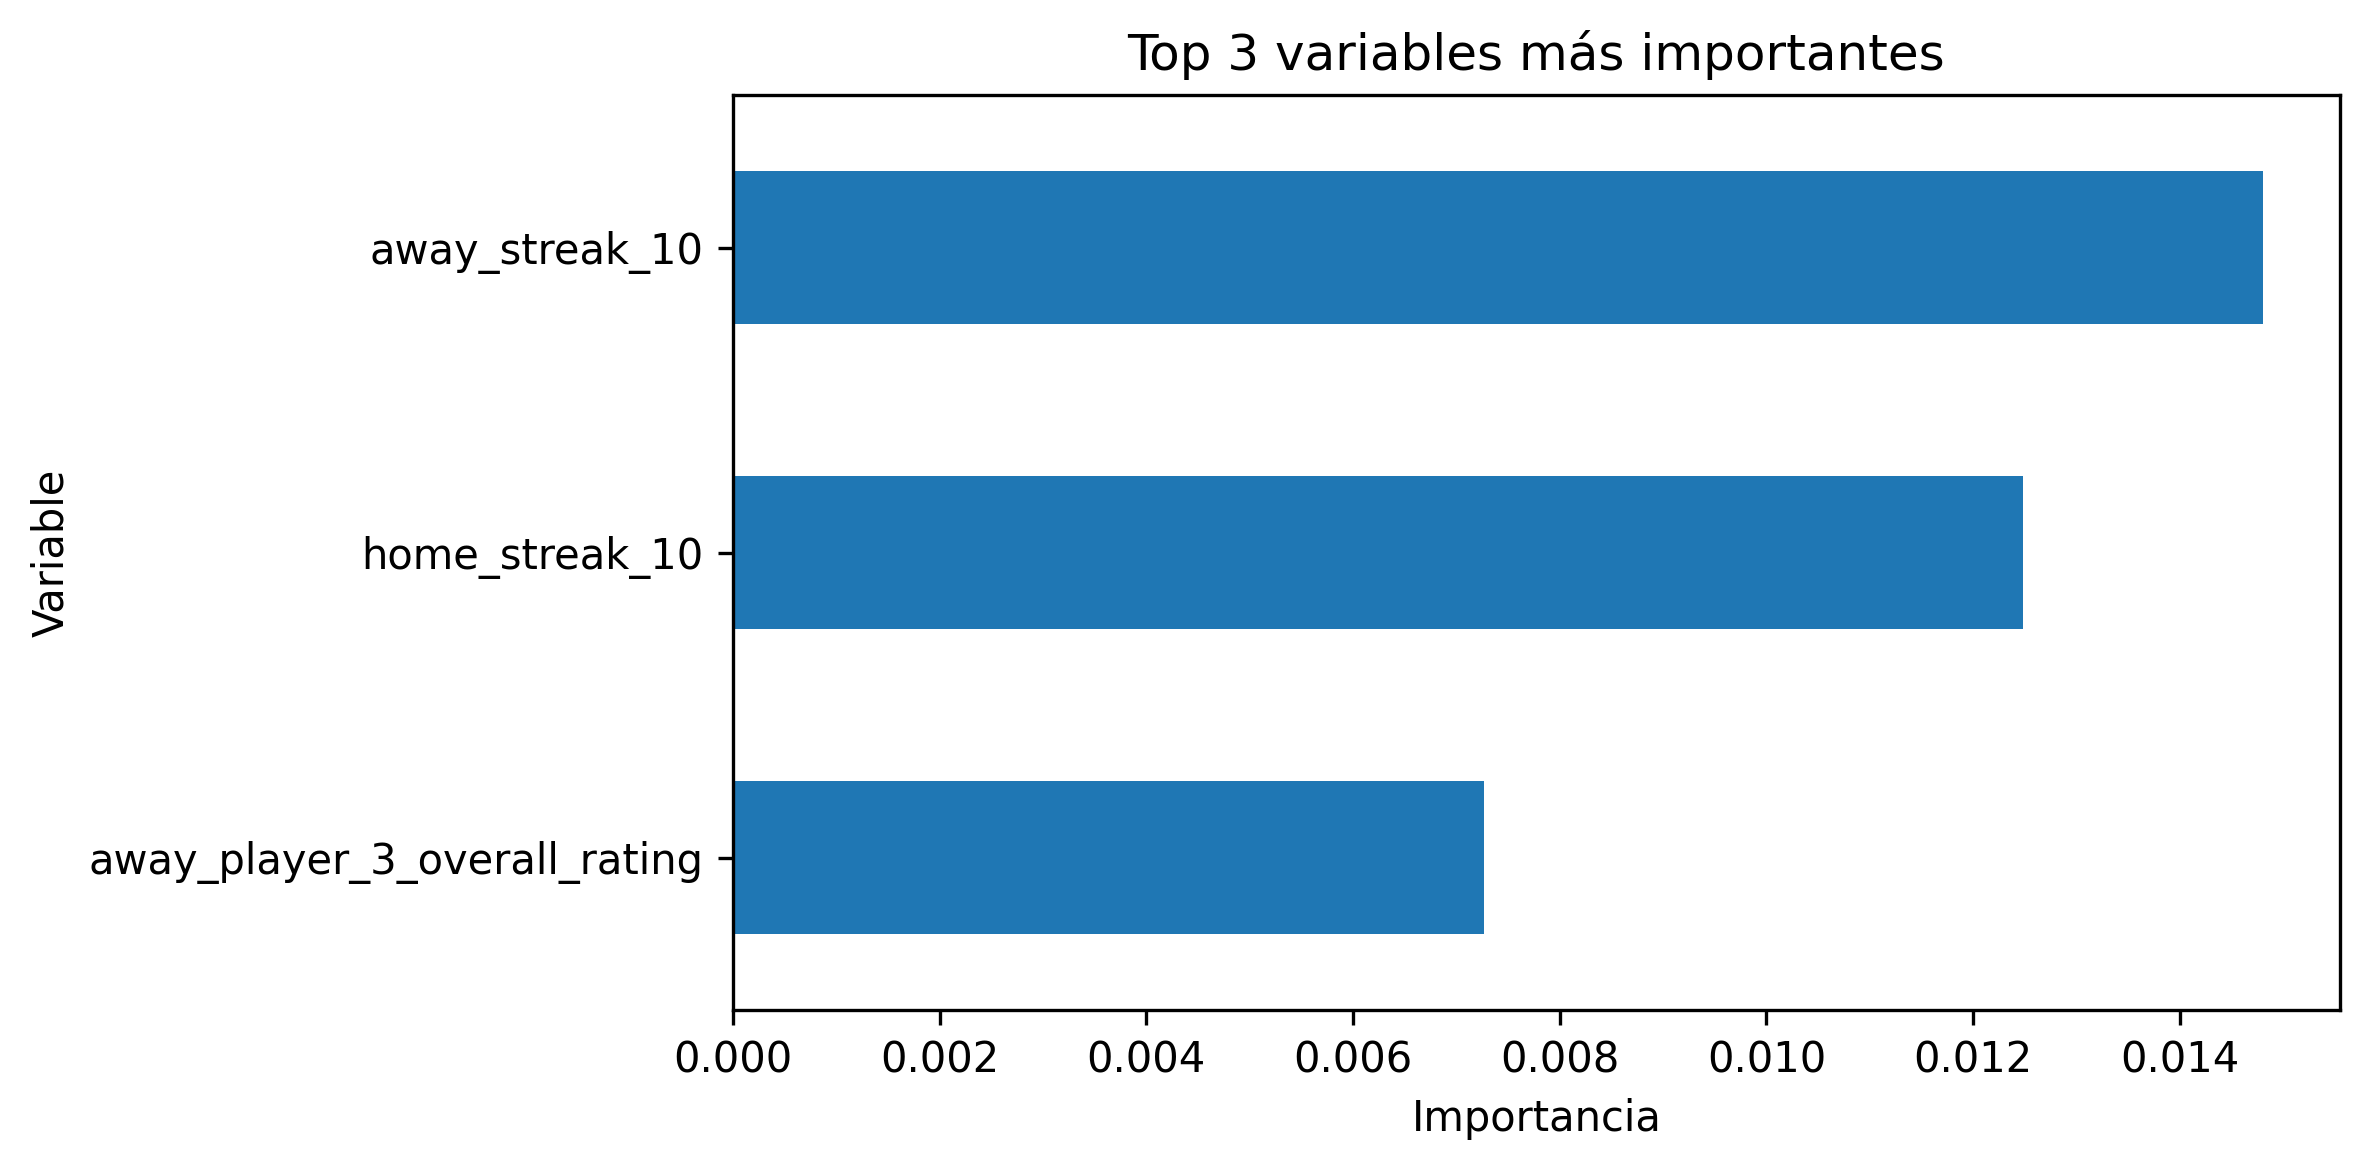

In [24]:
top5 = importances.sort_values(ascending=True).tail(3)
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 4), dpi=300)
top5.plot(kind="barh")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 3 variables más importantes")
plt.tight_layout()
plt.show()

## Complejidad del modelo

XGBoost es un ensamble de árboles de decisión entrenados secuencialmente (boosting). La complejidad total del modelo puede analizarse en dos niveles: la de cada árbol individual, acotada por `max_depth`, y la del ensamble completo, que surge de combinar `n_estimators` árboles por cada una de las `num_class` clases del problema.

Cada árbol está compuesto por dos tipos de nodos: nodos de partición (internos), que evalúan una condición sobre una feature y derivan hacia la izquierda o la derecha según el resultado, y nodos hoja (terminales), que contienen el valor numérico que ese árbol aporta a la predicción final de su clase. La profundidad máxima determina la cota superior teórica de nodos: un árbol binario completo de profundidad *d* tiene como máximo 2^(d+1) - 1 nodos. En la práctica, XGBoost suele detener una rama antes de alcanzar esa cota cuando no encuentra una partición que reduzca la pérdida; esto está regulado, incluso sin configurarlos explícitamente en este modelo, por los valores por defecto de `gamma` y `min_child_weight`.

In [25]:
booster = model.get_booster()
trees_df = booster.trees_to_dataframe()

is_leaf = trees_df["Feature"] == "Leaf"
nodes_per_tree = trees_df.groupby("Tree").size()
leaves_per_tree = trees_df[is_leaf].groupby("Tree").size()
splits_per_tree = trees_df[~is_leaf].groupby("Tree").size()

max_depth_param = model.get_params()["max_depth"]
max_nodos_teorico = 2 ** (max_depth_param + 1) - 1

print("Complejidad por árbol individual")
print(f"  max_depth configurado: {max_depth_param}")
print(f"  Nodos máximos teóricos por árbol: {max_nodos_teorico}")
print(f"  Nodos reales por árbol -> min: {nodes_per_tree.min()}, max: {nodes_per_tree.max()}, promedio: {nodes_per_tree.mean():.2f}")
print(f"  Nodos de partición por árbol -> promedio: {splits_per_tree.mean():.2f}")
print(f"  Nodos hoja por árbol -> promedio: {leaves_per_tree.mean():.2f}")

Complejidad por árbol individual
  max_depth configurado: 4
  Nodos máximos teóricos por árbol: 31
  Nodos reales por árbol -> min: 15, max: 31, promedio: 29.28
  Nodos de partición por árbol -> promedio: 14.14
  Nodos hoja por árbol -> promedio: 15.14


**Complejidad del ensamble (XGBoost completo)**

En clasificación multiclase, XGBoost entrena un árbol por clase en cada ronda de boosting. Por eso la cantidad total de árboles no es `n_estimators`, sino `n_estimators × num_class`. La suma de los nodos de todos esos árboles da la complejidad estructural total del modelo.

En un ensamble de árboles no existen "parámetros entrenables" en el sentido de una red neuronal (pesos y sesgos ajustados por gradiente), pero el concepto análogo más cercano son los valores hoja: cada hoja almacena un peso numérico aprendido durante el entrenamiento, y la suma de hojas de todos los árboles es, en la práctica, la cantidad de valores que el modelo aprendió. Los nodos de partición, en cambio, no almacenan un peso sino una condición (feature y umbral) determinada por el algoritmo de construcción a partir de la ganancia de información.

In [26]:
total_arboles = trees_df["Tree"].nunique()
total_nodos = len(trees_df)
total_hojas = int(is_leaf.sum())
total_splits = int((~is_leaf).sum())

params = model.get_params()
print(f"Total de árboles entrenados (n_estimators x num_class = {params['n_estimators']} x {params['num_class']}): {total_arboles}")
print(f"Total de nodos en el ensamble: {total_nodos}")
print(f"Total de nodos hoja (valores aprendidos): {total_hojas}")
print(f"Total de nodos de partición: {total_splits}")
print()
print("Hiperparámetros de configuración del ensamble:")
for k in ["objective", "num_class", "eval_metric", "n_estimators", "max_depth", "learning_rate", "tree_method", "random_state"]:
    print(f"  {k}: {params[k]}")

Total de árboles entrenados (n_estimators x num_class = 200 x 3): 600
Total de nodos en el ensamble: 17566
Total de nodos hoja (valores aprendidos): 9083
Total de nodos de partición: 8483

Hiperparámetros de configuración del ensamble:
  objective: multi:softprob
  num_class: 3
  eval_metric: mlogloss
  n_estimators: 200
  max_depth: 4
  learning_rate: 0.05
  tree_method: hist
  random_state: 42


## Persistencia del modelo

Junto con el modelo se guarda todo el contexto necesario para reconstruir features consistentes en una futura inferencia: columnas y orden esperado (`feature_columns`), las columnas estadísticas de cada entidad (`stat_cols_player`, `stat_cols_team`), los slots de jugador/equipo (`player_cols`, `team_cols`), las variables dinámicas de racha (`streak_cols`) y las medianas de imputación (`feature_medians`).

In [27]:
import joblib

joblib.dump({
    "model": model,
    "feature_columns": feature_columns,
    "stat_cols_player": stat_cols_player,
    "stat_cols_team": stat_cols_team,
    "player_cols": player_cols,
    "team_cols": team_cols,
    "streak_cols": streak_cols,
    "feature_medians": feature_medians,
}, "../../models/modelo_pred_pa_ta_streaks.joblib")

['../../models/modelo_pred_pa_ta_streaks.joblib']

## Inferencia a partir de IDs y Rachas

La función de inferencia requiere los vectores correspondientes a las identidades de los jugadores y equipos, además de los valores calculados de racha actualizados al momento inmediatamente previo al partido objetivo.

In [28]:
import sys
from pathlib import Path

root = Path.cwd()
while not (root / ".git").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root / "src"))

import joblib
from mineria.config import MODELS_DIR
from mineria.inference import build_fixture_features, predict_fixture

artifact = joblib.load(MODELS_DIR / "modelo_pred_pa_ta_streaks.joblib")
model = artifact["model"]
imputer = artifact["imputer"]
feature_columns = artifact["feature_columns"]


def build_match_features_with_streaks(home_player_ids, away_player_ids, home_team_id, away_team_id, streaks_dict):
    if len(home_player_ids) != 11 or len(away_player_ids) != 11:
        raise ValueError("Se requieren exactamente 11 IDs de jugador por equipo")
    return build_fixture_features(
        home_player_ids, away_player_ids, home_team_id, away_team_id,
        streaks=streaks_dict, recipe="combined",
    )


def predict_match(home_player_ids, away_player_ids, home_team_id, away_team_id, streaks_dict):
    proba, pred = predict_fixture(
        model, imputer, feature_columns,
        home_player_ids, away_player_ids, home_team_id, away_team_id,
        streaks=streaks_dict, recipe="combined",
    )
    labels = ["Home Win", "Draw", "Away Win"]
    print(f"Prediccion: {labels[pred]}")
    for label, p in zip(labels, proba):
        print(f"  {label}: {p:.1%}")
    return proba

**ARBOL**

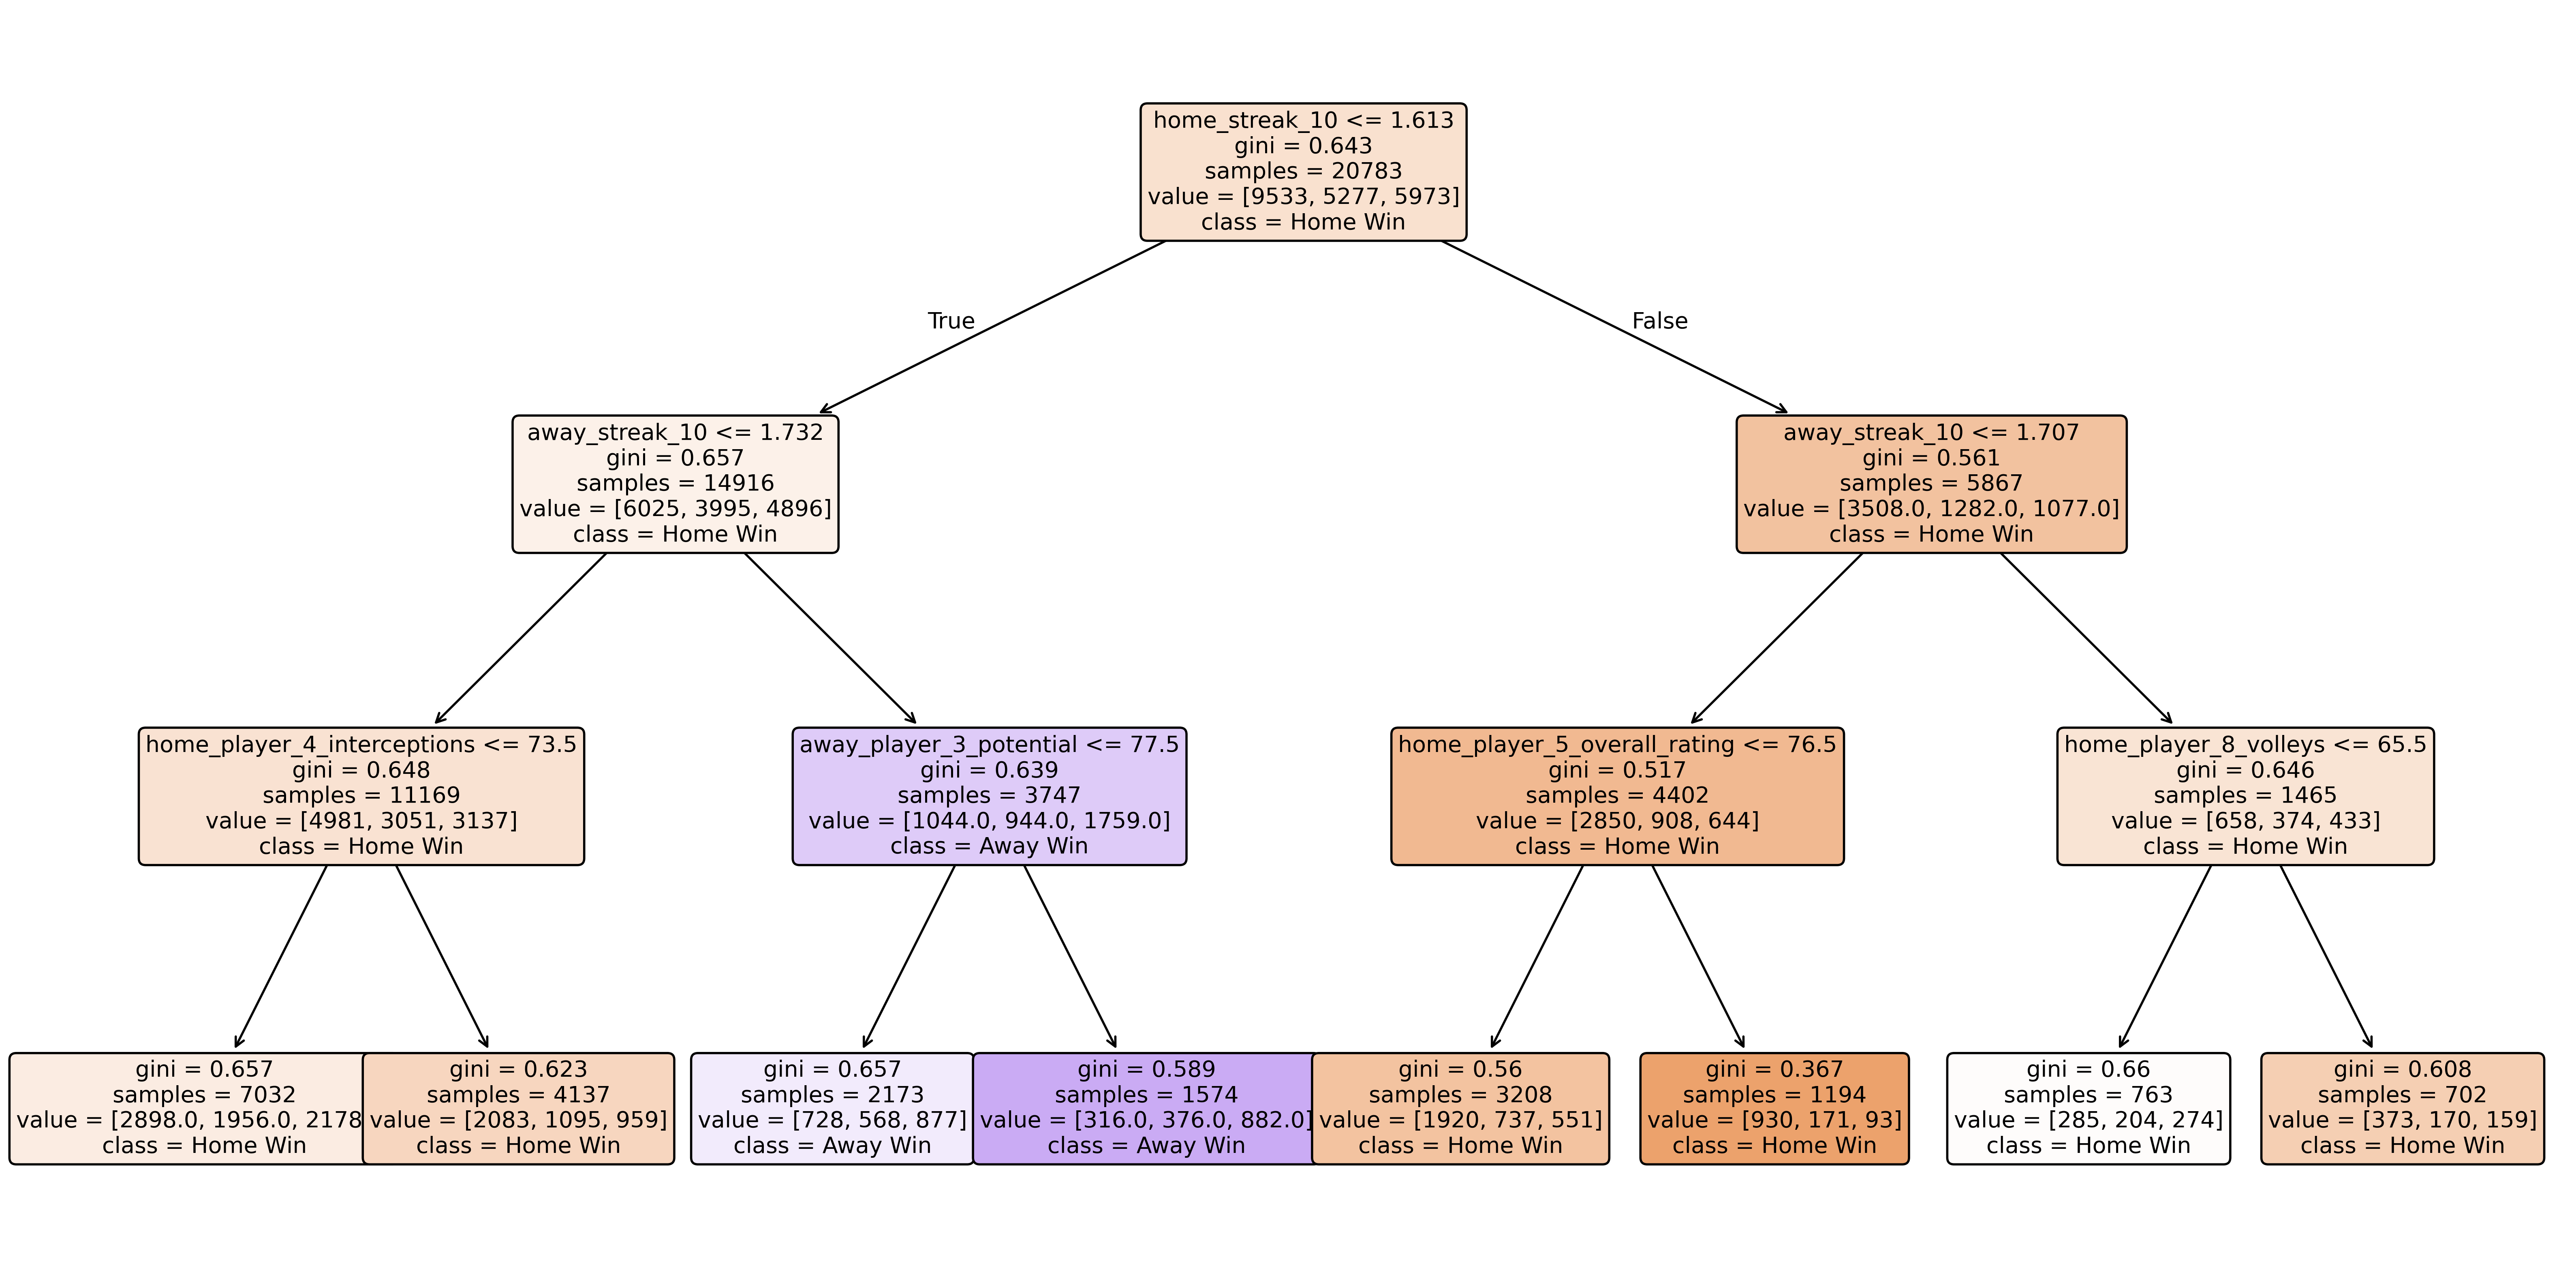

In [29]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

plt.figure(figsize=(20, 10), dpi=400)

plot_tree(
    model,
    feature_names=feature_columns,
    class_names=["Home Win", "Draw", "Away Win"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

# Redes Neuronales

In [ ]:
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.model_selection import train_test_split

# Primero separas el conjunto de prueba
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Luego divides el resto en entrenamiento y validación
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,  # ≈15% del total
    random_state=42,
    stratify=y_temp
)

model = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
)

model.fit(
    X_train.values,
    y_train.values,
    eval_set=[
        (X_valid.values, y_valid.values)
    ]
)

from sklearn.metrics import accuracy_score
import numpy as np

predictions = model.predict(X_test.values)
print(f"Accuracy test TabNet: {accuracy_score(y_test, predictions):.4f}")

c:\Users\admin\Documents\GitHub\Mineria\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


TypeError: Pandas DataFrame are not supported: apply X.values when calling fit